# Exercice 3.2 : Benchmark multi-détecteurs et Audit SOC
Dans cet atelier, nous comparons les 3 grands piliers d'anomalies en débit et latence, puis validons la détection sur les attaques réelles.

#### 1. Chargement et normalisation rapide

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler

data = pd.read_csv('data/UNSW_NB15_training-set.csv')
features = data.copy()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))
X_scaled = RobustScaler().fit_transform(features)
print("Données prêtes :", X_scaled.shape)

Données prêtes : (82332, 45)


#### 2. Benchmark des 3 grands piliers d'anomalies (comme Séance 1 ex2)

/home/hp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
100%|██████████| 3/3 [07:21<00:00, 147.19s/it]


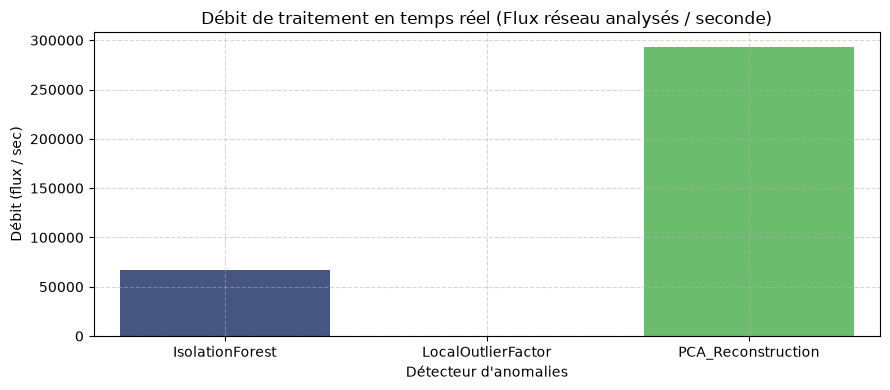

,modèle,train_time_sec,predict_time_single_ms,throughput_flows_per_sec
0,IsolationForest,1.147209,0.015006,66640.505861
1,LocalOutlierFactor,220.570869,2.642269,378.462578
2,PCA_Reconstruction,0.789691,0.003409,293326.558010


In [2]:
import time
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from helper import plot_benchmark_latency
from tqdm import tqdm

class PCADetector:
    def __init__(self, n_components=5):
        self.pca = PCA(n_components=n_components, random_state=42)
    def fit(self, X):
        self.pca.fit(X); return self
    def score_samples(self, X):
        return np.mean(np.square(X - self.pca.inverse_transform(self.pca.transform(X))), axis=1)

detectors = [
    ('IsolationForest', IsolationForest(n_estimators=100, random_state=42, n_jobs=-1)),
    ('LocalOutlierFactor', LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)),
    ('PCA_Reconstruction', PCADetector(n_components=5))
]

results = []
for name, model in tqdm(detectors):
    t0 = time.time(); model.fit(X_scaled); t_train = time.time() - t0
    t0 = time.time()
    sc = model.score_samples(X_scaled) if name == 'PCA_Reconstruction' else -model.score_samples(X_scaled)
    t_pred = time.time() - t0
    results.append({'modèle': name, 'train_time_sec': t_train,
                    'predict_time_single_ms': (t_pred/len(X_scaled))*1000,
                    'throughput_flows_per_sec': len(X_scaled)/t_pred})

df_results = pd.DataFrame(results)
plot_benchmark_latency(df_results)
df_results

#### 3. Audit SOC réel : Courbe ROC et matrice de confusion

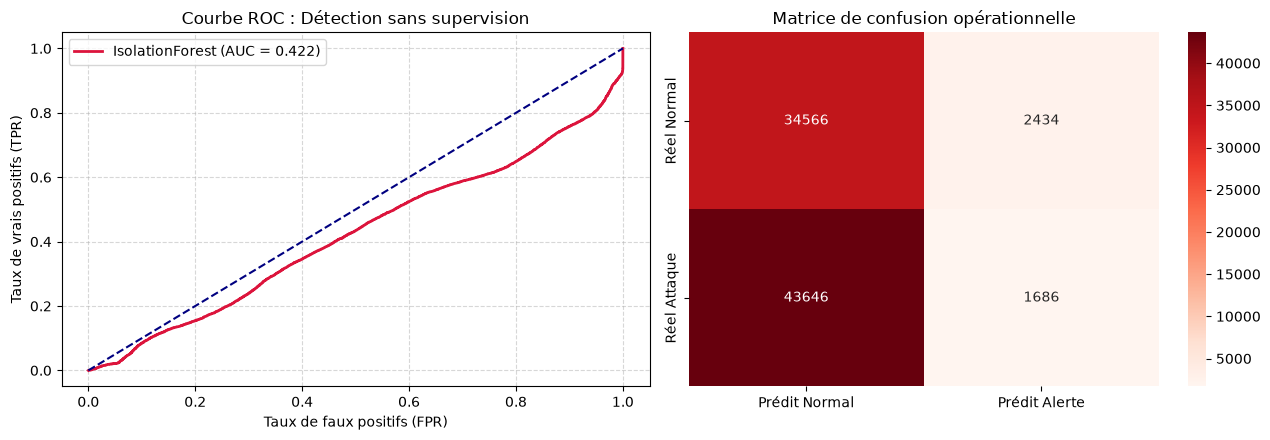


=== IsolationForest ===
              precision    recall  f1-score   support

      Normal     0.4420    0.9342    0.6000     37000
     Attaque     0.4092    0.0372    0.0682     45332

    accuracy                         0.4403     82332
   macro avg     0.4256    0.4857    0.3341     82332
weighted avg     0.4239    0.4403    0.3072     82332



In [ ]:
from helper import plot_roc_and_cm
from sklearn.metrics import classification_report

ground_truth = data['label']

for name, model in detectors:
    model.fit(X_scaled)

    if name == "PCA_Reconstruction":
        scores = model.score_samples(X_scaled)
    else:
        scores = -model.score_samples(X_scaled)

    pred_anomalies = (scores >= np.percentile(scores, 95)).astype(int)

    plot_roc_and_cm(ground_truth, scores, pred_anomalies, model_name=name)
    print(f"\n=== {name} ===")
    print(classification_report(
        ground_truth, pred_anomalies,
        target_names=['Normal', 'Attaque'],
        digits=4
    ))